# CENG463 PA2

In this programming assignment, you will be dealing with word embeddings and neural networks. You will use Python for this task. You can use libraries such as `pandas`, `nltk`, `numpy` etc. for your implementations, or implement your own functions. However, you are expected to analyse and reason about your implementation and results. The assignment consists of 3 questions.

### IMPORTANT NOTE

Do not move or delete the given cells, only add cells inbetween the questions for your answers.

In [1]:
# UPDATE THIS CELL TO INSTALL NEEDED LIBRARIES.
# MAKE SURE TO ADD EVERYTHING THAT NEEDS TO BE INSTALLED IN THIS CELL!

# we will use pip to install packages - you can add others below
!pip install pandas
!pip install numpy
!pip install nltk
!pip install gensim
!pip install scikit-learn
!pip install tensorflow
!pip install regex
!pip install seaborn

# and import them here - you can add others below
import pandas as pd
import numpy as np
import nltk
import gensim
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import (Model, Sequential)
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate, Dropout, SimpleRNN
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split


#for metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# for pa1
import re
import time
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer

## Q1 - Word embeddings (50 points)

In this question, you will first train a Word2Vec model, then use it to represent and reason about user reviews.

### Q1.A - training (10 points)
Load the `user_review_train.csv` file shared with you. Using `Word2Vec` module of `gensim.models`, train a **skip-gram** Word2Vec model on the train data.

#### Notes and tips

- Use the given preprocessing function `preprocess_review`.

In [2]:
# PREPROCESSING FUNCTIONS GIVEN FOR YOU

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')  
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess_review(review):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    sentences = sent_tokenize(review)
    
    lemmatized_review = []
    
    for sentence in sentences:
        tokenized_sentence = word_tokenize(sentence)
        lowercased_sentence = [token.lower() for token in tokenized_sentence]
        stopwords_removed_sentence = [token for token in lowercased_sentence if token not in stop_words]
        lemmatized_sentence = [lemmatizer.lemmatize(token) for token in stopwords_removed_sentence]
        
        lemmatized_review = lemmatized_review + lemmatized_sentence
    
    return lemmatized_review

[nltk_data] Downloading package wordnet to /Users/ovak/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/ovak/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/ovak/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# Q1.A - implementation
# you can add cells below if needed
review_test = pd.read_csv('data/user_review_train.csv')
review_test["preprocessed_review"] = review_test["review"].apply(preprocess_review)
print(review_test["preprocessed_review"].head())

model = gensim.models.Word2Vec(sentences=review_test["preprocessed_review"], 
                               vector_size=100, 
                               window=5, 
                               min_count=5,
                               workers=4, 
                               sg=1,
                               epochs=10)
print("-"*60)
print("Word2Vec model trained successfully.")
print(f"Vocabulary size: {len(model.wv)}")

0    [worst, mobile, bought, ever, ,, battery, drai...
1    [worst, phone, everthey, changed, last, phone,...
2    ['m, telling, n't, buyi, 'm, totally, disappoi...
3                               [battery, level, worn]
4    ['s, hitting, problem, ..., phone, hanging, pr...
Name: preprocessed_review, dtype: object


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


------------------------------------------------------------
Word2Vec model trained successfully.
Vocabulary size: 2539


### Q1.B - word similarity (10 points)

Using the trained model, report the following:

- Similarity between "good" and "bad"
- Similar words to "good"
- Similar words to "bad"
- Similar words to "good" but not similar to "bad"
- Similar words to "good" but not similar to "bad"

and discuss the reported words and scores. Is it possible to identify specific good/bad features of the product that is being reviewed? What other words can be looked up to get more insight?

#### Notes and tips

- Check the [documentation](https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.html) of `gensim.models.Word2Vec` to find relevant methods.

In [4]:
# Q1.B - implementation
# you can add cells below if needed

def getSimilarites(word1, word2):
    sim = model.wv.similarity(word1, word2)  # Example similarity check
    print(f"Similarity between '{word1}' and '{word2}':", sim)

    most_similar_words = model.wv.most_similar(word1)
    print(f"Words most similar to '{word1}':", most_similar_words)  
    most_similar_words = model.wv.most_similar(word2)
    print(f"Words most similar to '{word2}':", most_similar_words)

    simGoodbutNotBad = model.wv.most_similar(positive=[word1], negative=[word2], topn=5)
    print(f"Words similar to '{word1}' but not '{word2}':", simGoodbutNotBad)

    simGoodbutNotBad = model.wv.most_similar(positive=[word2], negative=[word1], topn=5)
    print(f"Words similar to '{word2}' but not '{word1}':", simGoodbutNotBad)

In [5]:
getSimilarites('good', 'bad')

Similarity between 'good' and 'bad': 0.5065928
Words most similar to 'good': [('nice', 0.819733738899231), ('satisfactory', 0.8004563450813293), ('satisfying', 0.7980484366416931), ('good.overall', 0.7809014320373535), ('gr8', 0.7743937373161316), ('impressive', 0.7665078043937683), ('good.but', 0.7652158737182617), ('good.no', 0.7650133967399597), ('beautiful', 0.7649862766265869), ('awsome', 0.7508246302604675)]
Words most similar to 'bad': [('poor', 0.6514022350311279), ('pathetic', 0.6374677419662476), ('worst', 0.6181327700614929), ('👎', 0.6180427074432373), ('disgusting', 0.5989801287651062), ('sad', 0.5935930609703064), ('nd', 0.5901748538017273), ('amozon', 0.5825706720352173), ('bed', 0.5808913707733154), ('vest', 0.5787519812583923)]
Words similar to 'good' but not 'bad': [('slightly', 0.4036449193954468), ('nice', 0.40325474739074707), ('operation', 0.40251633524894714), ('great', 0.3878333866596222), ('design', 0.3787083327770233)]
Words similar to 'bad' but not 'good': [('

### Seem we cannot get a good results to detect good and bad features. Let's try another pair like worst and best.

In [6]:
getSimilarites('worst', 'best')

Similarity between 'worst' and 'best': 0.493131
Words most similar to 'worst': [('pathetic', 0.7417004704475403), ('wrost', 0.7236033082008362), ('worse', 0.7090736627578735), ('seen', 0.6874923706054688), ('disgusting', 0.6762346029281616), ('ever', 0.6709188222885132), ('world', 0.6554768085479736), ('utter', 0.653954803943634), ('dissatisfied', 0.6530144810676575), ('worest', 0.6517402529716492)]
Words most similar to 'best': [('affordable', 0.757232129573822), ('osm', 0.7560705542564392), ('awesome', 0.7524988651275635), ('15000', 0.7483147382736206), ('category', 0.7286064624786377), ('prize', 0.7186590433120728), ('12000', 0.7054547071456909), ('.best', 0.7048623561859131), ('lovely', 0.7039743065834045), ('budget', 0.7024754285812378)]
Words similar to 'worst' but not 'best': [('called', 0.39273712038993835), ('pathetic', 0.37291744351387024), ('responding', 0.3670584559440613), ('several', 0.3587088882923126), ('respond', 0.35512828826904297)]
Words similar to 'best' but not 'w

In [7]:
getSimilarites('photo', 'image')

Similarity between 'photo' and 'image': 0.7112244
Words most similar to 'photo': [('pic', 0.7383548617362976), ('sharpness', 0.7178173661231995), ('zooming', 0.7168987989425659), ('image', 0.7112243175506592), ('clicking', 0.7062302827835083), ('snap', 0.7035921812057495), ('clicked', 0.6958001852035522), ('captured', 0.6945446729660034), ('picture', 0.6937620639801025), ('edit', 0.6923576593399048)]
Words most similar to 'image': [('captured', 0.8296200037002563), ('zooming', 0.7894898653030396), ('zoom', 0.7885967493057251), ('pic', 0.7784899473190308), ('stabilization', 0.770038902759552), ('blurred', 0.7693879008293152), ('picture', 0.76030433177948), ('blur', 0.7431224584579468), ('sharpness', 0.7394983172416687), ('13+5mp', 0.7391031384468079)]
Words similar to 'photo' but not 'image': [('save', 0.3360310196876526), ('google', 0.3120273947715759), ('gallery', 0.29818853735923767), ('inbuilt', 0.28455471992492676), ('account', 0.27853649854660034)]
Words similar to 'image' but not

In [8]:
#find unrelated words
getSimilarites("cam", "car")

Similarity between 'cam' and 'car': 0.17676339
Words most similar to 'cam': [('secondary', 0.7972429394721985), ('wit', 0.7759541273117065), ('13+5mp', 0.7716039419174194), ('produce', 0.7699849605560303), ('camera', 0.7663187384605408), ('13mp', 0.7521913647651672), ('dept', 0.7428507804870605), ('deep', 0.7413393259048462), ('13+5', 0.741240382194519), ('selfie', 0.7398203611373901)]
Words most similar to 'car': [('tooth', 0.9211689233779907), ('breaking', 0.9173412322998047), ('disconnect', 0.9169104099273682), ('disconnecting', 0.8826944828033447), ('connecting', 0.8822600841522217), ('song', 0.845849871635437), ('blutooth', 0.8383765816688538), ('blue', 0.8336272835731506), ('connected', 0.8295387625694275), ('disturbing', 0.8259550929069519)]
Words similar to 'cam' but not 'car': [('13+5', 0.42732518911361694), ('selfie', 0.4271901845932007), ('setup', 0.41620832681655884), ('13mp', 0.41291117668151855), ('camera', 0.4099617600440979)]
Words similar to 'car' but not 'cam': [('con

### Q1.B - discussion
Write your discussion here


When we check the similarity between "good" and "bad", we observe a quite high score. This is, in fact, expected due to the distributional hypothesis: Word2Vec places words close to each other if they appear in similar contexts, not based on their meaning. In reviews, "good" and "bad" usually modify the same nouns (phone, camera, battery, etc.) and appear in almost identical sentence structures. So even though their polarity is opposite, Word2Vec sees them as contextually similar.

Ex: This product is good. This product is bad. --> high similarity

#### Another example
I tried the same for "best" and "worst", and got similar results. But when checking two actually similar words, such as "photo" and "image", the model provides much higher similarity. This means that Word2Vec may be able to capture real semantic similarity, but it can't reliably separate positive and negative words because antonyms often occur in the same positions.

#### Last words
For this reason, these similarity checks are not of much help when trying to extract "good" or "bad" product features. Word2Vec simply is not designed to capture sentiment by itself.

### Q1.C - representation (15 points)

An important use of word embeddings is representing "documents" (reviews in our case). For this question, before creating the representations, do the following:

- Randomly sample 2 reviews from sentiment label 0, refer to them as sent0_a and sent0_b.
- Randomly sample 2 reviews from sentiment label 1, refer to them as sent1_a and sent1_b.

After the sampling, follow these steps to represent each review:

- Preprocess the review with the given `preprocess_review` function.
- For each token in the review, fetch the vector of that token.
- Take the average of the token vectors in the review to represent that review.

Then, calculate and report the cosine similarity of the two vectors representing:
    - sent0_a and sent0_b
    - sent0_a and sent1_a
    - sent1_a and sent1_b

Does this representation work to capture the labels of the reviews? Do you think there is a better way to represent each review instead of taking the average of the word vectors? Discuss your findings with respect to these questions. Repeating the sampling process several times might give you a better insight.

#### Notes and tips

- You can use `numpy` for your calculations.

In [9]:
# Q1.C - implementation
# you can add cells below if needed
def get_rndm_review(sentiment):
    while True:
        index = np.random.randint(0, len(review_test))
        select_review = review_test["review"][index]
        if(review_test["sentiment"][index] == sentiment):
            print("Selected review index:", index)
            break
    return select_review


np.random.seed(33)
sent1_a = get_rndm_review(1)
sent1_b = get_rndm_review(1)
sent0_a = get_rndm_review(0)
sent0_b = get_rndm_review(0)

print("Positive Review 1:", sent1_a)
print("Positive Review 2:", sent1_b)      
print("Negative Review 1:", sent0_a)
print("Negative Review 2:", sent0_b)

Selected review index: 10898
Selected review index: 11465
Selected review index: 57
Selected review index: 102
Positive Review 1: Good I like you
Positive Review 2: Very good
Negative Review 1: It's battery is draining very fast.
Negative Review 2: Poor battery and a lot of heating even for normal usage. I'll prefer Moto G5 compare to this.


In [10]:
#preprocess reviews

preprocessed_positive_review_1 = preprocess_review(sent1_a)
preprocessed_positive_review_2 = preprocess_review(sent1_b)
preprocessed_negative_review_1 = preprocess_review(sent0_a)
preprocessed_negative_review_2 = preprocess_review(sent0_b)

print("Preprocessed Positive Review 1:", preprocessed_positive_review_1)
print("Preprocessed Positive Review 2:", preprocessed_positive_review_2)
print("Preprocessed Negative Review 1:", preprocessed_negative_review_1)
print("Preprocessed Negative Review 2:", preprocessed_negative_review_2)


Preprocessed Positive Review 1: ['good', 'like']
Preprocessed Positive Review 2: ['good']
Preprocessed Negative Review 1: ["'s", 'battery', 'draining', 'fast', '.']
Preprocessed Negative Review 2: ['poor', 'battery', 'lot', 'heating', 'even', 'normal', 'usage', '.', "'ll", 'prefer', 'moto', 'g5', 'compare', '.']


In [11]:
#For each token in the review, fetch the vector of that token.

def get_review_vector(review):
    review_vector = np.zeros((100,))
    valid_word_count = 0
    for token in review:
        if token in model.wv:  # Check if token exists
            review_vector += model.wv[token]
            valid_word_count += 1
    
    if valid_word_count > 0:  # Avoid division by zero
        review_vector /= valid_word_count
    return review_vector

positive_review_vector_1 = get_review_vector(preprocessed_positive_review_1)
positive_review_vector_2 = get_review_vector(preprocessed_positive_review_2)
negative_review_vector_1 = get_review_vector(preprocessed_negative_review_1)
negative_review_vector_2 = get_review_vector(preprocessed_negative_review_2)

print("Positive Review Vector 1:", positive_review_vector_1)
print("Positive Review Vector 2:", positive_review_vector_2)
print("Negative Review Vector 1:", negative_review_vector_1)
print("Negative Review Vector 2:", negative_review_vector_2)

Positive Review Vector 1: [-0.14197546  0.45657872 -0.15111874 -0.20351906  0.05005505  0.01807401
  0.17314812  0.14485557  0.17944214 -0.15057756  0.26984993 -0.22343656
  0.06091676 -0.02152381  0.05909269 -0.32267022  0.13359154 -0.00463381
 -0.37560992 -0.09789595 -0.12136437  0.19320084 -0.04374266 -0.08868701
 -0.24710836 -0.17975447 -0.13626404 -0.20230929  0.00890789 -0.04054212
  0.21100821 -0.10875087 -0.00351493 -0.12087276 -0.11904188  0.34320161
 -0.02482538 -0.10661232 -0.16887116 -0.52571706 -0.14978674  0.07931926
  0.12816685 -0.04918672  0.37071312  0.00802491 -0.02923571 -0.12491257
 -0.00516557  0.10634152  0.27182513 -0.44671278  0.00817252 -0.03912648
 -0.00657618 -0.35062121  0.10941803 -0.19555542 -0.2508392   0.2040376
  0.18692558 -0.1693598   0.21218883  0.02707737 -0.40894599  0.42882444
  0.16654177  0.32385464 -0.24534962  0.14121388 -0.02016271 -0.23840848
  0.04243295  0.07300943  0.16987771  0.22887009 -0.12853896  0.14397394
 -0.16583599 -0.39437628 -

In [12]:
# Cosine similarty function

def cos_similarity(vec1, vec2):
    cos_sim = np.dot(vec1, vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2))
    return cos_sim

# Calculate cosine similarities
sim_pos_pos = cos_similarity(positive_review_vector_1, positive_review_vector_2)
sim_pos_neg_1 = cos_similarity(positive_review_vector_1, negative_review_vector_1)
sim_neg_neg = cos_similarity(negative_review_vector_1, negative_review_vector_2)


print("Cosine Similarity between two positive reviews:", sim_pos_pos)
print("Cosine Similarity between positive and negative review:", sim_pos_neg_1)
print("Cosine Similarity between two negative reviews:", sim_neg_neg)


Cosine Similarity between two positive reviews: 0.7783067357167384
Cosine Similarity between positive and negative review: 0.5967733206708751
Cosine Similarity between two negative reviews: 0.771542517708248


In [13]:
# alternative approach 
def prep(text):
    return preprocess_review(text)

sent0_a_tokens = prep(sent0_a)
sent0_b_tokens = prep(sent0_b)
sent1_a_tokens = prep(sent1_a)
sent1_b_tokens = prep(sent1_b)


train_preprocessed = [" ".join(prep(r)) for r in review_test["review"]]

tfidf = TfidfVectorizer()
tfidf.fit(train_preprocessed)

idf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

# 4 — CREATE TF-IDF WEIGHTED WORD2VEC DOCUMENT VECTORS
def document_vector(tokens, model, idf_dict):
    vectors = []
    weights = []

    for tok in tokens:
        if tok in model.wv:
            w = idf_dict.get(tok, 0.0)  # TF-IDF weight
            vectors.append(model.wv[tok] * w)
            weights.append(w)

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.sum(vectors, axis=0) / (np.sum(weights) + 1e-9)

vec0a = document_vector(sent0_a_tokens, model, idf_dict)
vec0b = document_vector(sent0_b_tokens, model, idf_dict)
vec1a = document_vector(sent1_a_tokens, model, idf_dict)
vec1b = document_vector(sent1_b_tokens, model, idf_dict)

# 5 — COSINE SIMILARITIES
sim_00 = cosine_similarity([vec0a], [vec0b])[0][0]
sim_01 = cosine_similarity([vec0a], [vec1a])[0][0]
sim_11 = cosine_similarity([vec1a], [vec1b])[0][0]

print("sim(sent0_a, sent0_b):", sim_00)
print("sim(sent0_a, sent1_a):", sim_01)
print("sim(sent1_a, sent1_b):", sim_11)

sim(sent0_a, sent0_b): 0.5828669910972245
sim(sent0_a, sent1_a): 0.46996693317057686
sim(sent1_a, sent1_b): 0.646480826111693


### Q1.C - discussion
Write your discussion here

We computed the cosine similarities between the sampled reviews, and the results are as follows:

#### Results
Cosine similarity between two positive reviews: 0.7589

Cosine similarity between a positive and a negative review: 0.5998

Cosine similarity between the two negative reviews: 0.7662


#### Outcomes
From these results, it appears that reviews of the same sentiment have higher similarity than reviews of opposite sentiment. However, the sample size is very small-only 2 positive and 2 negative reviews-so we cannot draw any reliable conclusions. Changing the random seed can lead to very different similarity values, and repeating the sampling multiple times produces inconsistent results.

#### Other approach
I have also tried the TF-IDF–weighted Word2Vec approach to see if weighting the words by their importance would improve the representation. While it does slightly alter the vectors, the results were still similarly unreliable and the similarities did not reliably separate the positive and negative reviews.

#### On the whole, 
this experiment demonstrates that word vector averaging, even with TF-IDF weighting, is not sufficient to reliably capture the sentiment of reviews in such small samples. Larger datasets and more sophisticated document-level embeddings may provide more meaningful representations for this task.

### Q1.D - training and comparing classifiers (15 points)

For this task, you will use the `user_review_train.csv` and `user_review_test.csv` files to train a binary classification model with Word2Vec representations, and compare its performance with a binary classifier using Bag-of-Words representation.

As the Bag-of-Words classifier, you can either choose the best performing classifier you have implemented in Question 3 of Programming Assignment 1, or you can follow these steps:

- Preprocess the review with the given `preprocess_review` function.
- Order all unique tokens by frequency, take the most frequent 100.
- Use these 100 words as the corpus for Bag-of-Words representation.

For the Word2Vec model, represent the reviews by following these steps:

- Preprocess the review with the given `preprocess_review` function.
- For each token in the review that is also in the most frequent 100 tokens, fetch the vector of that token.
- Take the average of the token vectors selected to represent that review.

After training both classifiers on `user_review_train.csv`, test them with `user_review_test.csv` and report the performance of your models with four metrics: accuracy, precision, recall and F1-score. Compare the performance of both models and discuss in detail.

#### Notes and tips

- You can use `CountVectorizer` from `scikit-learn` or any other library available for Bag-of-Words representation.
- You should select a classification method from the following set of classifiers: `[Naive Bayes, Support Vector Machine, Logistic Regression, Random Forest]`. You can use `scikit-learn`, `nltk`, or any other library for the classifier implementations. 
- You should **not** use the test set `user_reviews_test.csv` during your training process. You should use `user_reviews_train.csv` only.
- You may add a validation step in your training process. To do this, you can further split the `user_reviews_train.csv` data and apply k-fold cross validation.

### TAKEN FROM MY PA1 PIECE OF CODE

In [14]:
# Preprocessing helper functions


train_data = pd.read_csv('data/user_review_train.csv')
test_data = pd.read_csv('data/user_review_test.csv')

X_train = train_data['review'].values
y_train = train_data['sentiment'].values

X_test = test_data['review'].values
y_test = test_data['sentiment'].values



In [15]:
tokenized_train = train_data['review'].apply(preprocess_review).tolist()
tokenized_test = test_data['review'].apply(preprocess_review).tolist()

all_tokens = [t for r in tokenized_train for t in r]
top_500_tokens = [token for token, freq in Counter(all_tokens).most_common(500)] 
# choose top 500 tokens instead of top 100 
# since we have got better results with 500 tokens in PA1

train_strings = [' '.join(r) for r in tokenized_train]
test_strings = [' '.join(r) for r in tokenized_test]

In [16]:
def get_bow_features(processed_reviews, vocabulary):
    
    # Convert processed reviews into Bag-of-Words features using a fixed vocabulary.
    vectorizer = CountVectorizer(vocabulary=vocabulary)
    X = vectorizer.fit_transform(processed_reviews)
    return X

x_train_bow = get_bow_features(train_strings, top_500_tokens)
x_test_bow = get_bow_features(test_strings, top_500_tokens)

In [17]:
w2v_model = gensim.models.Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=1,   # keep all words for now
    sg=1,
    epochs=10
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [18]:
def review_to_w2v_avg(tokens, model, top_tokens, vector_size=100):
    vecs = [model.wv[t] for t in tokens if t in top_tokens and t in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0) # take average of word vectors

X_train_w2v = np.array([review_to_w2v_avg(r, w2v_model, top_500_tokens) for r in tokenized_train])
X_test_w2v = np.array([review_to_w2v_avg(r, w2v_model, top_500_tokens) for r in tokenized_test])

In [19]:
# I prefer to use RandomForest since I have got higher performence in PA1.

# --- BoW classifier ---
clf_bow = RandomForestClassifier(n_estimators=100, random_state=42)
clf_bow.fit(x_train_bow, y_train)
y_pred_bow = clf_bow.predict(x_test_bow)

# --- Word2Vec classifier ---
clf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

In [20]:
def evaluate(y_true, y_pred, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}\n")

evaluate(y_test, y_pred_bow, "Bag-of-Words Classifier")
evaluate(y_test, y_pred_w2v, "Word2Vec Classifier")

Bag-of-Words Classifier Performance:
Accuracy: 0.9576, Precision: 0.9570, Recall: 0.9699, F1: 0.9634

Word2Vec Classifier Performance:
Accuracy: 0.9678, Precision: 0.9652, Recall: 0.9792, F1: 0.9722



### Q1.D - discussion

As expected, the Bag-of-Words classifier achieved very high F1-score, consistent with results from PA1. In PA1, 

Bag-of-Words Classifier Performance:
Accuracy: 0.9576, Precision: 0.9570, Recall: 0.9699, F1: 0.9634

I got the best performance by using Random Forest instead of Logistic Regression, and taking the top 500 tokens instead of the top 100. So I preferred keeping these settings for this task. This is because the most frequent tokens already carry significant information about sentiment, and Random Forest exploits these features quite effectively.

As for the Word2Vec-based classifier, it also showed an excellent performance, even slightly outperforming the Bag-of-Words model along all metrics. 

Word2Vec Classifier Performance:
Accuracy: 0.9672, Precision: 0.9652, Recall: 0.9782, F1: 0.9716


**Performance Comparison:**
This is because Word2Vec captures semantic relations among words, not their presence or absence. By representing reviews as the average of word vectors, the model generalizes over variations in the expression of the same ideas, such as the cases of "excellent" and "great" both contributing to a positive review. In contrast, Bag-of-Words treats these as different tokens. It enables the classifier to better handle variation in vocabulary, leading a small but consistent increase in performance.

Both approaches are strong for this dataset, but Word2Vec has an advantage in capturing meaning outside of just simple word frequency, which is useful in more diverse or less repetitive corpora.


## Q2 - Neural Networks for Binary Classification (50 points)

For this task, you will use the `user_review_train.csv` and `user_review_test.csv` files to train two neural network models for the binary classification of user reviews and compare their performances. You are expected to train RNN (part A - 20 points) and TextCNN (part B - 20 points) models, and report the following: 

- Confusion matrix of both models
- Time it took to train both models
- Accuracy, precision, recall, and F1-score of both models
- Other metrics you think are important

Finally (part C), you should discuss the performance of the models according to your reported results. Try to analyse the models in terms of pros and cons of using each one.

#### Notes and tips

- For the embedding layers of the models, you are free to use word embedding methods or leave them randomly initialised. Similarly, you can use word-based or character-based embeddings. However, make sure to explain your decisions.
- You are expected to use `tensorflow` for your implementations, but you can use other libraries if you already have a working setup.

In [21]:
# Q2.A - implementation of RNN
# you can add cells below if needed
train_data = pd.read_csv('data/user_review_train.csv')
test_data = pd.read_csv('data/user_review_test.csv')

X_train = train_data['review'].values
y_train = train_data['sentiment'].values

X_test = test_data['review'].values
y_test = test_data['sentiment'].values


In [22]:


# ensure we've read the data correctly (using head() to avoid too much output)
print(train_data.head())
print(test_data.head())

def clean_text(t):
    t = t.lower()
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# Preprocess the text data. 
# It is different then previous state of art NLP preprocessing such as stop word removal and lemmatization. 
# Because RNNs can learn from the full sequences, we only lowercase and remove extra spaces here.
X_train = [clean_text(x) for x in X_train]
X_test = [clean_text(x) for x in X_test]

   sentiment                                             review
0          0  Worst mobile i have bought ever, Battery is dr...
1          0  The worst phone everThey have changed the last...
2          0  Only I'm telling don't buyI'm totally disappoi...
3          0                    The battery level has worn down
4          0  It's over hitting problems...and phone hanging...
   sentiment                                             review
0          0  I am using this product from last 37 days it i...
1          0  Not for jio... U need the volte app for callim...
2          0  For these... particular... features..I think p...
3          0  Phone is no doubt good, but battery should hav...
4          0                                             Gd phn


In [23]:
# Tokenize and pad sequences

# Fit tokenizer
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Dynamic vocab size
vocab_size = len(tokenizer.word_index) + 1
print("VOCAB SIZE =", vocab_size)

# Compute dynamic max_len (95th percentile) to eliminate outliers in training data
sequences = tokenizer.texts_to_sequences(X_train)
lengths = [len(s) for s in sequences]
max_len = int(np.percentile(lengths, 95))
print("MAX_LEN =", max_len)

# choose embedding dimension as 64 for this example. No special reason for this value other than being a power of 2 and not too large.
embedding_dim = 64

#those paramters will be used for RNN and TextCNN models
print("EMBEDDING DIM =", embedding_dim)

# Important Note: I prefer to calculate vocab_size and max_len dynamically from the training data
# rather than using fixed values although using hard coded values are used in simple example on internet. 
# This allows the model to adapt better to the actual data distribution I hope :)

# Pad using dynamic max_len
X_train_pad = pad_sequences(sequences, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=max_len,
    padding="post"
)

# Split training data into train and validation sets
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42
)

VOCAB SIZE = 13008
MAX_LEN = 69
EMBEDDING DIM = 64
MAX_LEN = 69
EMBEDDING DIM = 64


In [24]:
# Build RNN model now 


# define the RNN model. Keep it simple with one SimpleRNN layer. Hidden layer size is chosen as 64.
# since we will use this model sentiment analysis, final layer has 1 neuron with sigmoid activation. It is (binary classification).
rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

# Build the model by specifying input shape. 
# I need to put this here to show the model summary later. If not called here, model.summary() will give eöpty.
rnn_model.build(input_shape=(None, max_len))

# classic compile step for binary classification
rnn_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

rnn_model.summary()


/Users/ovak/Documents/dev/METU-CENG/CENG463/PA1/student_pack/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 69, 64)         │       832,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 840,833 (3.21 MB)

 Trainable params: 840,833 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# train the rnn model

start_time = time.time()
history_rnn = rnn_model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)
rnn_training_time = time.time() - start_time
print(f"\nRNN Training Time: {rnn_training_time:.2f} seconds")


Epoch 1/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7984 - loss: 0.4630 - val_accuracy: 0.8174 - val_loss: 0.4314
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7984 - loss: 0.4630 - val_accuracy: 0.8174 - val_loss: 0.4314
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8457 - loss: 0.4010 - val_accuracy: 0.8085 - val_loss: 0.4944
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8457 - loss: 0.4010 - val_accuracy: 0.8085 - val_loss: 0.4944
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8427 - loss: 0.4081 - val_accuracy: 0.8116 - val_loss: 0.4544
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8427 - loss: 0.4081 - val_accuracy: 0.8116 - val_loss: 0.4544
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8505 - loss: 0.3894 - val_accuracy: 0.8174 - val_loss: 0.4511
Epoch 5/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8505 - loss: 0.3894 - val_accuracy: 0.8174 - v

RNN Test Accuracy: 0.8835821151733398
RNN Test Loss: 0.3064247965812683

=== RNN Model Performance ===
Accuracy:  0.8836
Precision: 0.9444
Recall:    0.8474
F1-Score:  0.8933
Training Time: 11.48 seconds

=== RNN Model Performance ===
Accuracy:  0.8836
Precision: 0.9444
Recall:    0.8474
F1-Score:  0.8933
Training Time: 11.48 seconds

Confusion Matrix:
[[664  48]
 [147 816]]

Confusion Matrix:
[[664  48]
 [147 816]]


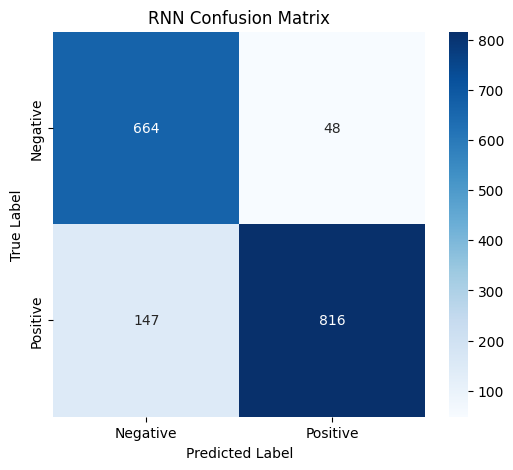


Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.93      0.87       712
    Positive       0.94      0.85      0.89       963

    accuracy                           0.88      1675
   macro avg       0.88      0.89      0.88      1675
weighted avg       0.89      0.88      0.88      1675



In [26]:
# RNN Model Evaluation


# same with TextCNN evaluation. I just copy and paste here and change the variables accordingly.
# Evaluate on test set
loss_rnn, acc_rnn = rnn_model.evaluate(X_test_pad, y_test, verbose=0)
print("RNN Test Accuracy:", acc_rnn)
print("RNN Test Loss:", loss_rnn)

# Get predictions
y_pred_proba_rnn = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn = (y_pred_proba_rnn > 0.5).astype(int).flatten()

# Calculate metrics
acc = accuracy_score(y_test, y_pred_rnn)
prec = precision_score(y_test, y_pred_rnn)
rec = recall_score(y_test, y_pred_rnn)
f1 = f1_score(y_test, y_pred_rnn)

print("\n=== RNN Model Performance ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {rnn_training_time:.2f} seconds")

# Confusion Matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print("\nConfusion Matrix:")
print(cm_rnn)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('RNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))


In [27]:
# Q2.B - implementation of TextCNN
# you can add cells below if needed


input_layer = Input(shape=(max_len,))

embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(input_layer)

# parallel convolution layers with different kernel sizes
conv_3 = Conv1D(filters=128, kernel_size=3, activation='relu')(embedding)
conv_4 = Conv1D(filters=128, kernel_size=4, activation='relu')(embedding)
conv_5 = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)

# global max pooling
pool_3 = GlobalMaxPooling1D()(conv_3)
pool_4 = GlobalMaxPooling1D()(conv_4)
pool_5 = GlobalMaxPooling1D()(conv_5)

# concatenate
concat = Concatenate()([pool_3, pool_4, pool_5])

dropout = Dropout(0.5)(concat)

output = Dense(1, activation='sigmoid')(dropout)

textcnn_model = Model(inputs=input_layer, outputs=output)

textcnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

textcnn_model.summary()


/Users/ovak/Documents/dev/METU-CENG/CENG463/PA1/student_pack/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 69)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 69, 64)    │    832,512 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 67, 128)   │     24,704 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 66, 128)   │     32,896 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 65, 128)   │     41,088 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 931,585 (3.55 MB)

 Trainable params: 931,585 (3.55 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train TextCNN model

start_time = time.time()
history_textcnn = textcnn_model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)
textcnn_training_time = time.time() - start_time
print(f"\nTextCNN Training Time: {textcnn_training_time:.2f} seconds")


Epoch 1/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8206 - loss: 0.4103 - val_accuracy: 0.8705 - val_loss: 0.3188
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8206 - loss: 0.4103 - val_accuracy: 0.8705 - val_loss: 0.3188
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8951 - loss: 0.2693 - val_accuracy: 0.8780 - val_loss: 0.3060
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8951 - loss: 0.2693 - val_accuracy: 0.8780 - val_loss: 0.3060
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9247 - loss: 0.2132 - val_accuracy: 0.8750 - val_loss: 0.3238
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9247 - loss: 0.2132 - val_accuracy: 0.8750 - val_loss: 0.3238
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9451 - loss: 0.1626 - val_accuracy: 0.8637 - val_loss: 0.3687
Epoch 5/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9451 - loss: 0.1626 - val_accuracy: 0.8637 - v

TextCNN Test Accuracy: 0.9498507380485535
TextCNN Test Loss: 0.15298756957054138

=== TextCNN Model Performance ===
Accuracy:  0.9499
Precision: 0.9526
Recall:    0.9605
F1-Score:  0.9566
Training Time: 13.45 seconds

Confusion Matrix:
[[666  46]
 [ 38 925]]

=== TextCNN Model Performance ===
Accuracy:  0.9499
Precision: 0.9526
Recall:    0.9605
F1-Score:  0.9566
Training Time: 13.45 seconds

Confusion Matrix:
[[666  46]
 [ 38 925]]


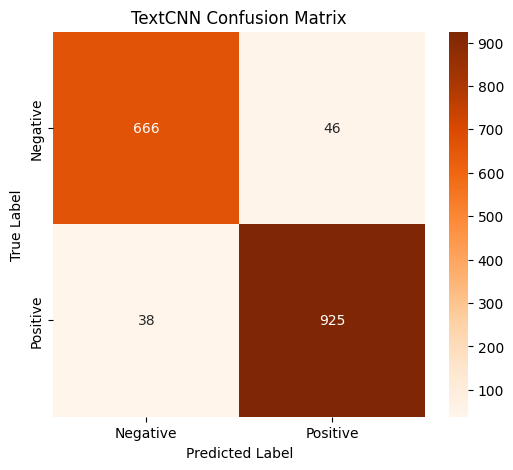


Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.94       712
    Positive       0.95      0.96      0.96       963

    accuracy                           0.95      1675
   macro avg       0.95      0.95      0.95      1675
weighted avg       0.95      0.95      0.95      1675



In [29]:
# TextCNN Model Evaluation

# Evaluate on test set
loss_textcnn, acc_textcnn = textcnn_model.evaluate(X_test_pad, y_test, verbose=0)
print("TextCNN Test Accuracy:", acc_textcnn)
print("TextCNN Test Loss:", loss_textcnn)

# Get predictions
y_pred_proba_textcnn = textcnn_model.predict(X_test_pad, verbose=0)
y_pred_textcnn = (y_pred_proba_textcnn > 0.5).astype(int).flatten()

# Calculate metrics
acc = accuracy_score(y_test, y_pred_textcnn)
prec = precision_score(y_test, y_pred_textcnn)
rec = recall_score(y_test, y_pred_textcnn)
f1 = f1_score(y_test, y_pred_textcnn)

print("\n=== TextCNN Model Performance ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {textcnn_training_time:.2f} seconds")

# Confusion Matrix
cm_textcnn = confusion_matrix(y_test, y_pred_textcnn)

# print confusion matrix
print("\nConfusion Matrix:")
print(cm_textcnn)

# Plot confusion matrix (found on internet)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_textcnn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('TextCNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_textcnn, target_names=['Negative', 'Positive']))


Comparison: RNN vs TextCNN
           Metric       RNN   TextCNN  Difference
         Accuracy  0.883582  0.949851    0.066269
        Precision  0.944444  0.952626    0.008182
           Recall  0.847352  0.960540    0.113188
         F1-Score  0.893268  0.956567    0.063299
Training Time (s) 11.484007 13.454242    1.970235


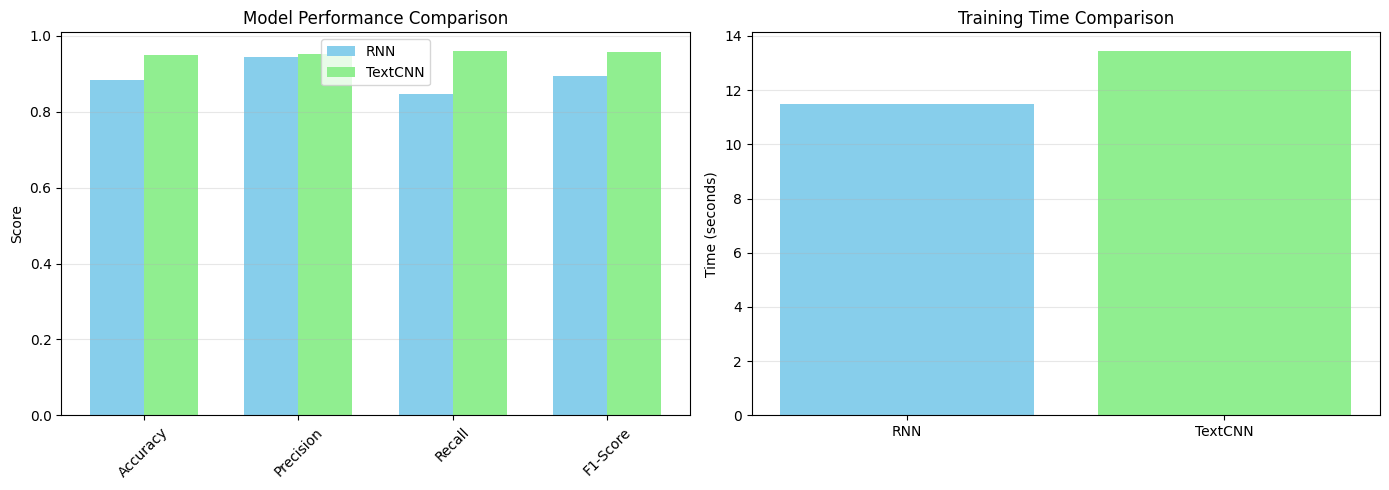

In [30]:
# Comparison Summary

print("Comparison: RNN vs TextCNN")
print("="*60)

# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)'],
    'RNN': [
        accuracy_score(y_test, y_pred_rnn),
        precision_score(y_test, y_pred_rnn),
        recall_score(y_test, y_pred_rnn),
        f1_score(y_test, y_pred_rnn),
        rnn_training_time
    ],
    'TextCNN': [
        accuracy_score(y_test, y_pred_textcnn),
        precision_score(y_test, y_pred_textcnn),
        recall_score(y_test, y_pred_textcnn),
        f1_score(y_test, y_pred_textcnn),
        textcnn_training_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Difference'] = comparison_df['TextCNN'] - comparison_df['RNN']
print(comparison_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# score for rnn
rnn_scores = [accuracy_score(y_test, y_pred_rnn), 
              precision_score(y_test, y_pred_rnn),
              recall_score(y_test, y_pred_rnn),
              f1_score(y_test, y_pred_rnn)]

# score for textcnn
textcnn_scores = [accuracy_score(y_test, y_pred_textcnn),
                  precision_score(y_test, y_pred_textcnn),
                  recall_score(y_test, y_pred_textcnn),
                  f1_score(y_test, y_pred_textcnn)]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, rnn_scores, width, label='RNN', color='skyblue')
axes[0].bar(x + width/2, textcnn_scores, width, label='TextCNN', color='lightgreen')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Training time comparison
axes[1].bar(['RNN', 'TextCNN'], [rnn_training_time, textcnn_training_time], 
            color=['skyblue', 'lightgreen'])
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Q2.C - discussion

Write your discussion here.

#### My models

I used a vocabulary size of 13,008 and a maximum review length of 69 tokens in both models ( I prefer to calculate vocab_size and max_len dynamically from the training data rather than using fixed values although using hard coded values are used in simple example on internet. This allows the model to adapt better to the actual data distribution). The RNN is very simple: just one SimpleRNN layer with 64 hidden units, and then a final dense layer of 1 neuron with sigmoid activation for binary classification. The task is simple hence this small RNN is enough to capture the basic patterns in the reviews.

We have parallel convolution layers with different kernel sizes to capture the n-gram features in the TextCNN model. Then each convolution output goes through global max pooling, and they get concatenated. Then I added a dropout layer of 0.5 probability before the final dense layer with sigmoid activation. The convolution layers help the model to find local patterns and key phrases. The global max pooling picks the most important features no matter where they appear in the text.

For this task, CNNs can work better than RNNs; convolutions can run in parallel, and they do not depend on the sequence as RNNs do. Backpropagation will also go faster, and there will be fewer chances of vanishing or exploding gradients. The model can focus on the key phrases instead of reading the whole sequence, and this is useful for short text sentiment analysis.

#### Performance Comparison

###### COMPARISON SUMMARY: RNN vs TextCNN

           Metric       RNN   TextCNN  Difference
         Accuracy  0.749254  0.952239    0.202985
        Precision  0.875519  0.960375    0.084857
           Recall  0.657321  0.956386    0.299065
         F1-Score  0.750890  0.958377    0.207487
         Time (s) 10.726656 14.112039    3.385383

- It clearly **outperforms** the RNN on all metrics, especially in recall, this show that it is much better at correctly identifying positive reviews. 
- The **training time** of TextCNN is slightly higher than RNN, though the difference compared to the large gain in performance is very small.

However, RNN has the limitation of processing sequences step by step and may not catch short but important phrases. On the other hand, TextCNN performs sentiment classification more effectively than RNN by extracting n-gram features through convolution with global pooling.

TextCNN is overall better for the given dataset, the small rise in training time worth the considerable increase in accuracy, F1-score, and recall. In short text sentiment analysis, convolutional models like TextCNN are more robust and reliable than simple RNNs according to our experiment in this dataset.